In [ ]:
!pip install uv -q
!uv pip install --system "sglang[all] @ git+https://github.com/sgl-project/sglang.git#subdirectory=python"
!uv pip install --system openai httpx -q

import subprocess
import time

import sglang as sgl
print(f"SGLang установлен версии {sgl.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 110.2 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 203 packages in 8.66s
Prepared 76 packages in 24.57s
Uninstalled 24 packages in 1.23s
Installed 76 packages in 302ms
 + addict==2.4.0
 + airportsdata==20260315
 + anthropic==0.86.0
 + apache-tvm-ffi==0.1.9
 + av==16.1.0
 - blobfile==3.2.0
 + blobfile==3.0.0
 + build==1.4.0
 + cache-dit==1.3.0
 + compressed-tensors==0.13.0
 - cuda-python==12.9.4
 + cuda-python==12.9.0
 + diskcache==5.6.3
 + flash-attn-4==4.0.0b4
 + flashinfer-cubin==0.6.6
 + flashinfer-python==0.6.6
 + gguf==0.18.0
 + grpcio-health-checking==1.78.0
 + grpcio-reflection==1.78.0
 - imageio==2.37.3
 + imageio==2.36.0
 - imageio-ffmpeg==0.6.0
 + imageio-ffmpeg==0.5.1
 + interegular==0.3.3
 + jedi==0.19.2
 + llguidance==0.7.30
 + loguru==0.7.3
 + mistral-common==1.10.0
 + modelscope==1.35.1
 - moviepy==1.0.3
 + moviepy==2.2.1
 + msgspec==0.20.0
 + ninja==1.13.0
 + nvidia-cudnn-frontend==1.20.0
 +

работа FSM и экстракшн сырого текста в json формат - вау

In [ ]:
import json
import sglang as sgl
import time
# 1. Определяем промпт-программу с помощью декоратора
@sgl.function
def extract_character_info(s, description):
    # Системный промпт кэшируется в Radix Tree и не пересчитывается для каждого запроса
    s += sgl.system("You are an expert data extractor. Extract the character information strictly into JSON format.")
    s += sgl.user(description)

    # 2. Магия FSM: Определяем строгий шаблон JSON
    # Модель физически не сможет сгенерировать текст, нарушающий этот regex
    regex_pattern = r"""\{\n  "name": "[\w\s]+",\n  "age": \d+,\n  "weapon": "[\w\s]+"\n\}"""

    # Генерируем ответ, принудительно направляя вероятности токенов по regex-графу
    s += sgl.assistant(sgl.gen("json_output", regex=regex_pattern, temperature=0.1))

if __name__ == "__main__":
    print("Инициализация SGLang Runtime (загрузка весов в VRAM)...")
    # Запускаем локальный рантайм.
    # disable_cuda_graph=True иногда полезен в Colab для экономии памяти при инициализации
    runtime = sgl.Runtime(model_path="Qwen/Qwen3.5-4B", dtype="bfloat16")
    sgl.set_default_backend(runtime)

    # Подготовим небольшой батч данных
    texts = [
        "Geralt of Rivia is a witcher. He is 95 years old and uses a silver sword to slay monsters.",
        "Luke Skywalker is 19 years old. He wields a blue lightsaber and fights the Empire.",
        "Arthur Pendragon, aged 35, pulled the legendary sword Excalibur from the stone."
    ]

    requests = [{"description": t} for t in texts]

    print("\n Запуск пакетной обработки (Batch FSM Extraction)...")
    start = time.perf_counter()

    # Отправляем батч. SGLang автоматически распараллелит запросы.
    states = extract_character_info.run_batch(requests)

    latency = time.perf_counter() - start

    print(f"\n Батч выполнен за: {latency:.2f} сек")
    print("-" * 40)

    for i, state in enumerate(states):
        print(f"Исходный текст: {texts[i]}")
        # Вытаскиваем сгенерированный JSON по ключу "json_output"
        raw_json = state["json_output"]

        # Проверяем, что это действительно парсится как JSON в Python
        parsed_dict = json.loads(raw_json)
        print(f"Извлеченный JSON: {json.dumps(parsed_dict, ensure_ascii=False, indent=2)}\n")

    # 3. ОСВОБОЖДАЕМ ПАМЯТЬ
    # Это критически важно для следующих шагов с сервером
    print("\n Остановка Runtime и очистка VRAM...")
    runtime.shutdown()
    import torch, gc
    gc.collect()
    torch.cuda.empty_cache()
    print("Шаг 2 завершен.")

Инициализация SGLang Runtime (загрузка весов в VRAM)...



 Запуск пакетной обработки (Batch FSM Extraction)...

 Батч выполнен за: 2.63 сек
----------------------------------------
Исходный текст: Geralt of Rivia is a witcher. He is 95 years old and uses a silver sword to slay monsters.
Извлеченный JSON: {
  "name": "Geralt of Rivia",
  "age": 95,
  "weapon": "silver sword"
}

Исходный текст: Luke Skywalker is 19 years old. He wields a blue lightsaber and fights the Empire.
Извлеченный JSON: {
  "name": "Luke Skywalker",
  "age": 19,
  "weapon": "blue lightsaber"
}

Исходный текст: Arthur Pendragon, aged 35, pulled the legendary sword Excalibur from the stone.
Извлеченный JSON: {
  "name": "Arthur Pendragon",
  "age": 35,
  "weapon": "Excalibur"
}


 Остановка Runtime и очистка VRAM...
Шаг 2 завершен.


Продемонстрируем работу RadixAttention на большом контексте, и увидем, что если второй запрос относится к теме первого, то он просто подтягивает KV-cache из старого. Кэширование префиксов, чтобы префил второго реквеста был меньше

In [ ]:
import sglang as sgl
import time

@sgl.function
def qa_bot(s, context, question):
    s += sgl.system(context)
    s += sgl.user(question)
    s += sgl.assistant(sgl.gen("answer", max_tokens=1024, temperature=0.9))

if __name__ == "__main__":
    print(" Поднимаем Runtime с защитой от OOM")

    # ИСПОЛЬЗУЕМ ЗАЩИТНЫЕ ПАРАМЕТРЫ ДЛЯ КОЛАБА
    runtime = sgl.Runtime(
        model_path="Qwen/Qwen3.5-4B",
        dtype="bfloat16",
        mem_fraction_static=0.8,   # Берем только 80% VRAM под кэш, оставляем запас
        chunked_prefill_size=4096   # Бьем длинный промпт на чанки по 4к токенов, чтобы не взорвать память
    )
    sgl.set_default_backend(runtime)

    # Имитируем огромный контекст 2546 на 4 = 10к
    long_context = """Efficient KV Cache Reuse with RadixAttention
SGLang programs can chain multiple generation calls and create parallel copies with the "fork" primitive. Additionally, different program instances often share some common parts (e.g., system prompts). These scenarios create many shared prompt prefixes during execution, leading to numerous opportunities for reusing the KV cache. During LLM inference, the KV cache stores intermediate tensors from the forward pass, reused for decoding future tokens. They are named after key-value pairs in the self-attention mechanism vaswani2017attention. KV cache computation depends only on prefix tokens. Therefore, requests with the same prompt prefix can reuse the KV cache, reducing redundant computation and memory usage. More background and some examples are provided in Appendix A. //

Given the KV cache reuse opportunity, a key challenge in optimizing SGLang programs is reusing the KV cache across multiple calls and instances. While some systems explore certain KV cache reuse cases kwon2023vllm; ye2024chunkattention; juravsky2024hydragen; gim2023prompt, they often need manual configurations and cannot handle all reuse patterns (e.g., dynamic tree structures). Consequently, most state-of-the-art inference systems recompute the KV cache for each request. We will discuss their limitations and our differences in Sec. 7.

This section introduces RadixAttention, a novel technique for automatic and systematic KV cache reuse during runtime. Unlike existing systems that discard the KV cache after a generation request finishes, our system retains the cache for prompts and generation results in a radix tree, enabling efficient prefix search, reuse, insertion, and eviction. We implement an LRU eviction policy and a cache-aware scheduling policy to enhance the cache hit rate. RadixAttention is compatible with techniques like continuous batching yu2022orca, paged attention kwon2023vllm, and tensor parallelism shoeybi2019megatron. In addition, it introduces only negligible memory and time overhead when there is no cache hit.

RadixAttention. A radix tree is a data structure that serves as a space-efficient alternative to a classical trie (prefix tree). Unlike typical trees, the edges of a radix tree can be labeled not just with single elements but also with sequences of elements of varying lengths, significantly enhancing efficiency. In our system, we utilize a radix tree to manage a mapping between sequences of tokens, and their corresponding KV cache tensors. These KV cache tensors are stored in a non-contiguous, paged layout, where the size of each page is equivalent to one token. Because GPU memory is quickly filled by the KV cahce, we introduce a simple LRU eviction policy that evicts the least recently used leaf first. By evicting leaves first, we enable the re-use of their common ancestors until those ancestors become leaves and are also evicted.

In the continuous batching setting, we cannot evict nodes used by the currently running batch. Therefore, each node maintains a reference counter indicating how many running requests are using it. A node is evictable if its reference counter is zero. Note that we do not preallocate a fixed-size memory pool as a cache. Instead, we let the cached tokens and the currently running requests share the same memory pool. Therefore, the system dynamically allocates memory for cache and running requests. When enough waiting requests run, the system will evict all cached tokens in favor of a larger batch size. Fig. 3 shows how the radix tree is maintained for several incoming requests. The frontend interpreter sends full prompts to the runtime, and the runtime performs prefix matching and reuse. The tree structure is stored on the CPU with negligible maintenance overhead. During the execution of the fork primitive, the frontend sends the prefix first as a hint, ensuring the prefix is correctly inserted into the tree. It then sends the remaining prompts. This "Frontend Hint" simplifies runtime scheduling and matching, exemplifying the benefits of frontend-runtime co-design.

Cache-aware scheduling. We define the cache hit rate as
number of cached prompt tokens
number of prompt tokens
. When there are many requests in the waiting queue, the order in which they are executed can significantly impact the cache hit rate. For example, if the request scheduler frequently switches between different, unrelated requests, it can lead to cache thrashing and a low hit rate. We design a cache-aware scheduling algorithm to increase the cache hit rate. In the batch-processing setting we sort the requests by matched prefix length and prioritize requests with longer matched prefixes instead of using a first-come, first-served schedule. Alg. 1 (Appendix) shows the pseudo-code for cache-aware scheduling with contiguous batching. The algorithm uses longest-shared-prefix-first order. In more latency-sensitive settings we may still be able to tolerate limited batch re-ordering to improve cache reuse. Additionally, we prove the following theorem for optimal scheduling in the offline case. 1

Theorem 3.1.
For a batch of requests, we can achieve an optimal cache hit rate by visiting the radix tree of the requests in the depth-first search order, with a cache size
≥
 the maximum request length. The longest-shared-prefix-first order is equivalent to a depth-first search order.

The proof is in Sec. A.3 (Appendix). In the online case, the DFS order will be disrupted, but our schedule still approximates the DFS behavior on the augmented part of the full radix tree, as described in Sec. A.3. While greedy cache-aware scheduling can achieve high throughput, it can lead to starvation. We leave its integration with other fair scheduling methods sheng2023fairness as future work.

Distributed Cases. RadixAttention can be extended to multiple GPUs. For tensor parallelism, each GPU maintains a sharded KV cache. There is no need for additional synchronization because the tree operations are the same. Data parallelism with multiple workers is discussed in Sec. A.4 (Appendix).

4 Efficient Constrained Decoding with Compressed Finite State Machine
In LM programs, users often want to constrain the model’s output to follow specific formats, such
as JSON schemas. This can improve controllability and robustness, and make the output easier to
parse. SGLang offers a regex argument to enforce such constraints using regular expressions, which
are expressive enough for many practical scenarios. Existing systems support this by converting a
regular expression into a finite state machine (FSM) [54]. During decoding, they maintain the current
FSM state, retrieve allowed tokens from the next states, and set the probability of invalid tokens to
zero, decoding token by token. This token-by-token approach, however, is inefficient when there are
opportunities to decode multiple tokens at once. For example, the constant sequence {"summary":
" in Fig. 2 spans multiple tokens in the normal decoding process as shown in Fig. 4 (c), requiring
multiple decoding stages, even though there is only one valid next token when decoding it. Therefore,
the whole sequence can be decoded in a single step (i.e., forward pass). However, existing systems
can only decode one token at a time because the lack of integration between the FSM and the model
runner in existing systems prevents multi-token processing, resulting in slow decoding.
SGLang overcomes this limitation by creating a fast constrained decoding runtime with a compressed
FSM. This runtime analyzes the FSM and compresses adjacent singular-transition edges in the FSM
into single edges as demonstrated in Fig. 4 (b), allowing it to recognize when multiple tokens can be
decoded together. In Fig. 4 (d), multiple tokens on the compressed transition edge can be decoded in
one forward pass, which greatly accelerates the decoding process. It is also general and applicable to
all regular expressions. More details on the background and implementation are in Appendix B.
5 Efficient Endpoint Calling with API Speculative Execution
The previous sections introduced optimizations for open-weight models, which require modifications
to the model inference process. Additionally, SGLang works with API-access-only models, such as
OpenAI’s GPT-4. However, for these models, we can only call a black-box API endpoint.
This section introduces a new optimization for black-box API models that accelerates execution
and reduces the API cost of multi-call SGLang programs using speculative execution. For example, a program may ask the model to generate a description of a character with a multi-call

pattern: s += context + "name:" + gen("name", stop="\n") + "job:" + gen("job",
stop="\n"). Naively, the two gen primitives correspond to two API calls, meaning that the user
needs to pay for the input token fee on the context twice. In SGLang, we can enable speculative
execution on the first call and let it continue the generation of a few more tokens by ignoring the stop
condition. The interpreter keeps the additional generation outputs and matches and reuses them with
later primitives. In certain cases, with careful prompt engineering, the model can correctly match the
template with high accuracy, saving us the latency and input costs of one API call.
6 Evaluation
We evaluate the performance of SGLang across diverse LLM workloads. Subsequently, we conduct
ablation studies and case studies to demonstrate the effectiveness of specific components. SGLang is
implemented in PyTorch [37] with custom CUDA kernels from FlashInfer [59] and Triton [48].
6.1 Setup
Models. We test dense Llama-2 models [49], sparse mixture of experts Mixtral models [17], multimodal LLaVA image [27] and video models [62], and API model OpenAI’s GPT-3.5. For open-weight
models, the number of parameters ranges from 7 billion to 70 billion, and we use float16 precision.
Hardware. We run most experiments on AWS EC2 G5 instances, which are equipped with NVIDIA
A10G GPUs (24GB). We run 7B models on a single A10G GPU and larger models on multiple A10G
GPUs with tensor parallelism [44]. We run some additional experiments on A100G (80GB) GPUs.
Baselines. We compare SGLang against both high-level programming systems with their respective
languages and default runtimes, as well as low-level inference engines with standard OpenAI-like
Completion APIs. Unless otherwise stated, we do not turn on optimizations that will change the
computation results so that all systems compute the same results. The baselines include:
• Guidance[13], a language for controlling LLMs. We use Guidance v0.1.8 with llama.cpp backend.
• vLLM [23], a high-throughput inference engine. We use vLLM v0.2.5 and its default API server3
.
• LMQL [4], a query language. We use LMQL v0.7.3 with Hugging Face Transformers backend.
Workloads. We test the following: 5-shot MMLU [14] and 20-shot HellaSwag [61] benchmarks.
We decode one token for MMLU and use primitive select to select the answer with the highest
probability for HellaSwag. For the ReAct agent [57] and generative agents [36], we extract the
traces from the original papers and replay them. We use the Tree-of-thought [56] for the GSM-8K
problems and Skeleton-of-thought [33] for tip generation. We use LLM judges with the branch-solvemerge [40] technique; JSON decoding with a schema specified by a regular expression; Multi-turn
chat with 4 turns, where the input of each turn is randomly sampled between 256-512 tokens. Multiturn chat (short) means short output (4-8 tokens) and multi-turn chat (long) means long output
(256-512 tokens); DSPy retrieval-augmented generation (RAG) pipeline [20] in its official example.
Metrics. We report two performance metrics: throughput and latency. For throughput, we run a
sufficiently large batch of program instances to compute the maximum throughput, comparing the
number of program instances executed per second (programs per second, p/s). For latency, we execute
a single program at a time without batching and report the average latency for multiple instances.
""" * 4

    print("\n ЗАПРОС 1 (Холодный старт - строим Radix Tree)...")
    start_1 = time.perf_counter()
    state_1 = qa_bot.run(context=long_context, question="О чем этот текст? Ответь одним словом.")
    latency_1 = time.perf_counter() - start_1
    print(f" Время Запроса 1: {latency_1:.8f} сек")
    print(f"Ответ: {state_1['answer'].strip()}")

    print("\nЗАПРОС 2 (Radix Cache Hit)...")
    start_2 = time.perf_counter()
    state_2 = qa_bot.run(context=long_context, question="Какая технология упоминается в тексте?")
    latency_2 = time.perf_counter() - start_2
    print(f" Время Запроса 2: {latency_2:.8f} сек")
    print(f" Ответ: {state_2['answer'].strip()}")

    if latency_2 > 0:
        speedup = latency_1 / latency_2
        print(f"\n Итог: Второй запрос обработан в {speedup:.4f} раз быстрее!")

    print("\n Очистка VRAM...")
    runtime.shutdown()
    import torch, gc
    gc.collect()
    torch.cuda.empty_cache()
    print(" Шаг 2.5 успешно завершен.")

 Поднимаем Runtime с защитой от OOM

 ЗАПРОС 1 (Холодный старт - строим Radix Tree)...
 Время Запроса 1: 0.00067395 сек
Ответ: Текст представляет собой техническую статью о системе SGLang и методах оптимизации её работы. Основная тема текста — это

<think>

</think>

Текст представляет собой техническую статью о системе SGLang и методах оптимизации её работы. Основная тема текста — это высокоэффективное управление вычислительными ресурсами при генерации текста моделями больших языковых моделей. Одна-два слова недостаточно для отражения сути, но если строго следовать требованию **«одним словом»**, то:

**Оптимизация**

ЗАПРОС 2 (Radix Cache Hit)...
 Время Запроса 2: 0.00038714 сек
 Ответ: Please provide the text content for analysis.

<think>

</think>

Основываясь на предоставленном тексте, упомянутой технологией является **RadixAttention**.

Это новаторская техника, предложенная в работе над системой **SGLang**, которая предназначена для автоматического и систематического **повторного

Посмотрим на метрики (любимое) SGlang инференса через докер и графану как из гайда репы сгланга

upd: была попытка, но url страница лагала

🛠 1. Инициализация надежного Docker-демона...
✅ Docker работает стабильно.

🛠 2. Создание конфигурации Grafana и Prometheus...

⏳ 3. Запуск контейнеров мониторинга...
--- Контейнеры в работе ---
{.Names}   {.Status}   {.Ports}

⏳ 4. Поднимаем бэкенд SGLang (порт 30000)...
Ждем 35 секунд для загрузки весов модели в VRAM...

⏳ 5. Настройка внешнего туннеля (LocalTunnel)...

🌐 ССЫЛКА НА GRAFANA:
👉 your url is: https://legal-lies-throw.loca.lt
🔐 ПАРОЛЬ ДЛЯ ТУННЕЛЯ (Твой IP-адрес):
34.126.87.152
🔑 Логин в Grafana: admin
🔑 Пароль в Grafana: admin

🚀 6. Запуск фонового генератора трафика...
✅ Готово! Переходи по ссылке выше.


Квантизируем модель опираясь на sglang/examples/usage
/modelopt_quantize_and_export.py

на A100

In [ ]:
# 2. Устанавливаем SGLang и библиотеку квантования NVIDIA ModelOpt
!pip install uv -q
!uv pip install --system "sglang[all] @ git+https://github.com/sgl-project/sglang.git#subdirectory=python"
!uv pip install --system nvidia-modelopt[all] -q



print("🛠 1. Лечим конфликт библиотек (Protobuf)...")
# Устанавливаем стабильную версию protobuf, чтобы убрать ошибку MessageFactory
!pip install protobuf==3.20.3 -q

print(" DONE.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 91.0 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 203 packages in 12.09s
Prepared 76 packages in 22.28s
Uninstalled 24 packages in 1.56s
Installed 76 packages in 2.55s
 + addict==2.4.0
 + airportsdata==20260315
 + anthropic==0.86.0
 + apache-tvm-ffi==0.1.9
 + av==16.1.0
 - blobfile==3.2.0
 + blobfile==3.0.0
 + build==1.4.0
 + cache-dit==1.3.0
 + compressed-tensors==0.13.0
 - cuda-python==12.9.4
 + cuda-python==12.9.0
 + diskcache==5.6.3
 + flash-attn-4==4.0.0b4
 + flashinfer-cubin==0.6.6
 + flashinfer-python==0.6.6
 + gguf==0.18.0
 + grpcio-health-checking==1.78.0
 + grpcio-reflection==1.78.0
 - imageio==2.37.3
 + imageio==2.36.0
 - imageio-ffmpeg==0.6.0
 + imageio-ffmpeg==0.5.1
 + interegular==0.3.3
 + jedi==0.19.2
 + llguidance==0.7.30
 + loguru==0.7.3
 + mistral-common==1.10.0
 + modelscope==1.35.1
 - moviepy==1.0.3
 + moviepy==2.2.1
 + msgspec==0.20.0
 + ninja==1.13.0
 + nvidia-cudnn-frontend==1.20.0
 +

In [ ]:
# 1. Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Этот скрипт качает 7 ГБ оригинальных весов, сожмет до FP8 и сложит мне на Диск.

In [ ]:
import os
import torch
from sglang.srt.configs.device_config import DeviceConfig
from sglang.srt.configs.load_config import LoadConfig
from sglang.srt.configs.model_config import ModelConfig
from sglang.srt.distributed.parallel_state import init_distributed_environment, initialize_model_parallel
from sglang.srt.model_loader.loader import get_model_loader

print("⚙️ Настройка окружения ModelOpt...")
if not torch.distributed.is_initialized():
    os.environ["RANK"] = "0"
    os.environ["WORLD_SIZE"] = "1"
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    os.environ["LOCAL_RANK"] = "0"

    init_distributed_environment(world_size=1, rank=0, local_rank=0, backend="nccl")
    initialize_model_parallel(tensor_model_parallel_size=1, pipeline_model_parallel_size=1)

# ВОЗВРАЩАЕМСЯ НА СТАБИЛЬНУЮ КЛАССИЧЕСКУЮ АРХИТЕКТУРУ
model_path = "Qwen/Qwen2.5-7B-Instruct"
export_dir = "/content/drive/MyDrive/Qwen2.5-7B-FP8-ModelOpt"
os.makedirs(export_dir, exist_ok=True)

model_config = ModelConfig(
    model_path=model_path,
    quantization="modelopt_fp8",
    trust_remote_code=True,
)

load_config = LoadConfig(modelopt_export_path=export_dir)
device_config = DeviceConfig(device="cuda")

print(f"\n🚀 ЗАПУСК КВАНТОВАНИЯ НА A100: {model_path} -> FP8")
print(f"📁 Целевая папка (Google Drive): {export_dir}")
print("Процесс пошел. Можешь идти отдыхать!")

try:
    # Запуск движка компрессии
    model_loader = get_model_loader(load_config, model_config)
    model_loader.load_model(model_config=model_config, device_config=device_config)

    print("\n✅ КВАНТОВАНИЕ ЗАВЕРШЕНО УСПЕШНО!")
    print("\n--- Содержимое папки на Google Drive ---")
    get_ipython().system(f'ls -lh "{export_dir}"')

except Exception as e:
    print(f"\n❌ Ошибка во время квантования: {e}")

⚙️ Настройка окружения ModelOpt...


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


🚀 ЗАПУСК КВАНТОВАНИЯ НА A100: Qwen/Qwen2.5-7B-Instruct -> FP8
📁 Целевая папка (Google Drive): /content/drive/MyDrive/Qwen2.5-7B-FP8-ModelOpt
Процесс пошел. Можешь идти отдыхать!


...

Registered <class 'transformers.models.qwen2.modeling_qwen2.Qwen2Attention'> to _QuantAttention for KV Cache quantization
Inserted 703 quantizers


/usr/local/lib/python3.12/dist-packages/modelopt/torch/quantization/nn/modules/quant_module.py:81: UserWarning: Distributed training is initialized but no parallel_state is set for <class 'modelopt.torch.opt.dynamic.QuantQwen2Attention'>. Using default parallel_state which has data_parallel_group set to the default process group and tensor_parallel_group is unspecified. If you are using tensor parallelism for this module, you should set the parallel_state in its `_setup` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/modelopt/torch/quantization/nn/modules/quant_module.py:81: UserWarning: Distributed training is initialized but no parallel_state is set for <class 'modelopt.torch.opt.dynamic.QuantLinear'>. Using default parallel_state which has data_parallel_group set to the default process group and tensor_parallel_group is unspecified. If you are using tensor parallelism for this module, you should set the parallel_state in its `_setup` method.
  warnings.warn(
100%|█

model.layers.0.self_attn.q_proj.input_quantizer                                  TensorQuantizer((4, 3) bit fake per-tensor amax=21.8750 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.q_proj.output_quantizer                                 TensorQuantizer(disabled)
model.layers.0.self_attn.q_proj.weight_quantizer                                 TensorQuantizer((4, 3) bit fake per-tensor amax=0.5391 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.k_proj.input_quantizer                                  TensorQuantizer((4, 3) bit fake per-tensor amax=21.8750 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.k_proj.output_quantizer                                 TensorQuantizer(disabled)
model.layers.0.self_attn.k_proj.weight_quantizer                                 TensorQuantizer((4, 3) bit fake per-tensor amax=0.2207 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.v_proj.input_quantizer                                  TensorQuantizer((4, 3) bit fake

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/modelopt/torch/export/unified_export_hf.py:417: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weight_scaling_factor = torch.tensor(weight_quantizer.amax / weight_quantizer.maxbound)



✅ КВАНТОВАНИЕ ЗАВЕРШЕНО УСПЕШНО!

--- Содержимое папки на Google Drive ---
total 8.2G
-rw------- 1 root root  605 Mar 23 01:06 added_tokens.json
-rw------- 1 root root 2.5K Mar 23 01:06 chat_template.jinja
-rw------- 1 root root 2.2K Mar 23 01:06 config.json
-rw------- 1 root root  243 Mar 23 01:06 generation_config.json
-rw------- 1 root root  239 Mar 23 01:06 hf_quant_config.json
-rw------- 1 root root 1.6M Mar 23 01:06 merges.txt
-rw------- 1 root root 4.7G Mar 23 01:06 model-00001-of-00002.safetensors
-rw------- 1 root root 3.5G Mar 23 01:06 model-00002-of-00002.safetensors
-rw------- 1 root root  61K Mar 23 01:06 model.safetensors.index.json
-rw------- 1 root root  613 Mar 23 01:06 special_tokens_map.json
-rw------- 1 root root 4.6K Mar 23 01:06 tokenizer_config.json
-rw------- 1 root root  11M Mar 23 01:06 tokenizer.json
-rw------- 1 root root 2.7M Mar 23 01:06 vocab.json


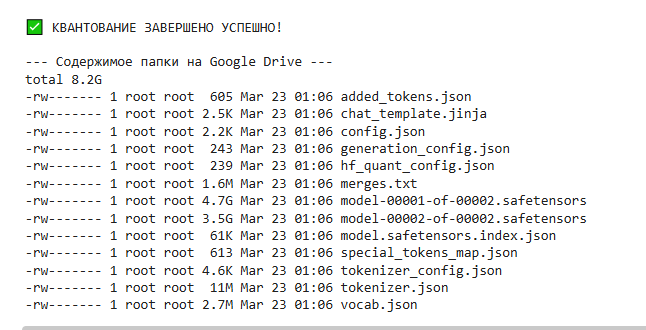

Квантизируем квена 2.5 32B

для него требуется не самый новый protobuf
хотелось кванитизовать 3.5 квены, но всё ломает Gated Delta Net

In [ ]:
!pip install uv -q
!uv pip install --system "sglang[all] @ git+https://github.com/sgl-project/sglang.git#subdirectory=python"
!uv pip install --system nvidia-modelopt[all] -q
!pip install protobuf==3.20.3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 97.2 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 203 packages in 12.35s
Prepared 76 packages in 27.10s
Uninstalled 24 packages in 1.13s
Installed 76 packages in 296ms
 + addict==2.4.0
 + airportsdata==20260315
 + anthropic==0.86.0
 + apache-tvm-ffi==0.1.9
 + av==16.1.0
 - blobfile==3.2.0
 + blobfile==3.0.0
 + build==1.4.0
 + cache-dit==1.3.0
 + compressed-tensors==0.13.0
 - cuda-python==12.9.4
 + cuda-python==12.9.0
 + diskcache==5.6.3
 + flash-attn-4==4.0.0b4
 + flashinfer-cubin==0.6.6
 + flashinfer-python==0.6.6
 + gguf==0.18.0
 + grpcio-health-checking==1.78.0
 + grpcio-reflection==1.78.0
 - imageio==2.37.3
 + imageio==2.36.0
 - imageio-ffmpeg==0.6.0
 + imageio-ffmpeg==0.5.1
 + interegular==0.3.3
 + jedi==0.19.2
 + llguidance==0.7.30
 + loguru==0.7.3
 + mistral-common==1.10.0
 + modelscope==1.35.1
 - moviepy==1.0.3
 + moviepy==2.2.1
 + msgspec==0.20.0
 + ninja==1.13.0
 + nvidia-cudnn-frontend==1.20.0
 +

In [ ]:
# 1. Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import torch
from sglang.srt.configs.device_config import DeviceConfig
from sglang.srt.configs.load_config import LoadConfig
from sglang.srt.configs.model_config import ModelConfig
from sglang.srt.distributed.parallel_state import init_distributed_environment, initialize_model_parallel
from sglang.srt.model_loader.loader import get_model_loader

print("⚙️ Настройка окружения ModelOpt...")
if not torch.distributed.is_initialized():
    os.environ["RANK"] = "0"
    os.environ["WORLD_SIZE"] = "1"
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    os.environ["LOCAL_RANK"] = "0"

    init_distributed_environment(world_size=1, rank=0, local_rank=0, backend="nccl")
    initialize_model_parallel(tensor_model_parallel_size=1, pipeline_model_parallel_size=1)

# БЕРЕМ МОДЕЛЬ НА 32 МИЛЛИАРДА ПАРАМЕТРОВ
model_path = "Qwen/Qwen2.5-32B-Instruct"

# СОХРАНЯЕМ НА ЛОКАЛЬНЫЙ ДИСК КОЛАБА (на Google Диск не влезет!)
export_dir = "/content/drive/Qwen2.5-32B-FP8-ModelOpt"
os.makedirs(export_dir, exist_ok=True)

model_config = ModelConfig(
    model_path=model_path,
    quantization="modelopt_fp8",
    trust_remote_code=True,
)

load_config = LoadConfig(modelopt_export_path=export_dir)
device_config = DeviceConfig(device="cuda")

print(f"\n🚀 ЗАПУСК КВАНТОВАНИЯ НА A100 (80GB): {model_path} -> FP8")
print(f"📁 Целевая папка (Локальный диск Colab): {export_dir}")
print("Это займет время (скачивание 64 ГБ весов + компрессия). Ждем...")

try:
    # Запуск движка компрессии
    model_loader = get_model_loader(load_config, model_config)
    model_loader.load_model(model_config=model_config, device_config=device_config)

    print("\n✅ КВАНТОВАНИЕ 32B-МОДЕЛИ ЗАВЕРШЕНО УСПЕШНО!")
    print("\n--- Содержимое папки с готовой моделью ---")
    get_ipython().system(f'ls -lh "{export_dir}"')

except Exception as e:
    print(f"\n❌ Ошибка во время квантования: {e}")

⚙️ Настройка окружения ModelOpt...


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


🚀 ЗАПУСК КВАНТОВАНИЯ НА A100 (80GB): Qwen/Qwen2.5-32B-Instruct -> FP8
📁 Целевая папка (Локальный диск Colab): /content/Qwen2.5-32B-FP8-ModelOpt
Это займет время (скачивание 64 ГБ весов + компрессия). Ждем...


...

Inserted 1603 quantizers


100%|██████████| 15/15 [01:22<00:00,  5.47s/it]


model.layers.0.self_attn.q_proj.input_quantizer                                  TensorQuantizer((4, 3) bit fake per-tensor amax=6.7500 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.q_proj.output_quantizer                                 TensorQuantizer(disabled)
model.layers.0.self_attn.q_proj.weight_quantizer                                 TensorQuantizer((4, 3) bit fake per-tensor amax=0.4648 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.k_proj.input_quantizer                                  TensorQuantizer((4, 3) bit fake per-tensor amax=6.7500 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.k_proj.output_quantizer                                 TensorQuantizer(disabled)
model.layers.0.self_attn.k_proj.weight_quantizer                                 TensorQuantizer((4, 3) bit fake per-tensor amax=0.4297 calibrator=MaxCalibrator quant)
model.layers.0.self_attn.v_proj.input_quantizer                                  TensorQuantizer((4, 3) bit fake p

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/modelopt/torch/export/unified_export_hf.py:417: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weight_scaling_factor = torch.tensor(weight_quantizer.amax / weight_quantizer.maxbound)



✅ КВАНТОВАНИЕ 32B-МОДЕЛИ ЗАВЕРШЕНО УСПЕШНО!

--- Содержимое папки с готовой моделью ---
total 32G
-rw-r--r-- 1 root root  605 Mar 23 01:22 added_tokens.json
-rw-r--r-- 1 root root 2.5K Mar 23 01:22 chat_template.jinja
-rw-r--r-- 1 root root 3.1K Mar 23 01:22 config.json
-rw-r--r-- 1 root root  243 Mar 23 01:20 generation_config.json
-rw-r--r-- 1 root root  239 Mar 23 01:20 hf_quant_config.json
-rw-r--r-- 1 root root 1.6M Mar 23 01:22 merges.txt
-rw-r--r-- 1 root root 4.7G Mar 23 01:20 model-00001-of-00007.safetensors
-rw-r--r-- 1 root root 4.6G Mar 23 01:21 model-00002-of-00007.safetensors
-rw-r--r-- 1 root root 4.6G Mar 23 01:21 model-00003-of-00007.safetensors
-rw-r--r-- 1 root root 4.6G Mar 23 01:21 model-00004-of-00007.safetensors
-rw-r--r-- 1 root root 4.6G Mar 23 01:21 model-00005-of-00007.safetensors
-rw-r--r-- 1 root root 4.6G Mar 23 01:21 model-00006-of-00007.safetensors
-rw-r--r-- 1 root root 4.6G Mar 23 01:22 model-00007-of-00007.safetensors
-rw-r--r-- 1 root root 138K Mar 

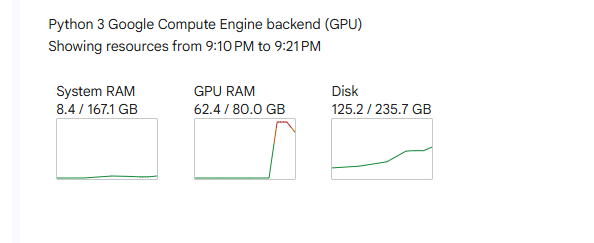 В момент квантизирования 32B


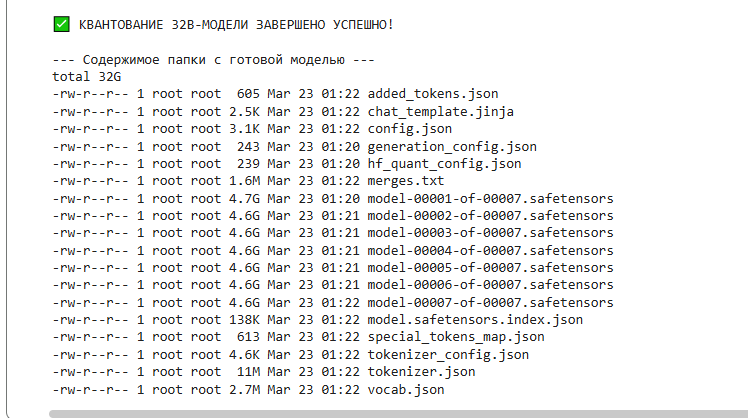